# S6E10 — 00 EDA: Airline Passenger Satisfaction

> **Pipeline position:** **00 EDA** → `01_baseline` → `02_features_experiments` → `03_final_features` → modelling (`04`–`11`)

| | |
|---|---|
| **Goal** | Understand the data before any model: what each column means, data quality, how every feature relates to the target, and whether train and test look alike. Every finding ends in a **decision** for modelling (collected in section 11). |
| **Input** | `data/raw/train.csv`, `data/raw/test.csv` |
| **Output** | none: findings and decisions only |
| **Runtime** | ≈ 1–2 min |

**The dataset in one paragraph.** A synthetic airline passenger survey generated from a real one (129,880 rows, used later as the "original data"). 699,635 train rows and 299,844 test rows. Each row is one passenger: 4 passenger/trip categories, age, flight distance, two delay columns and 13 service ratings on a 1–5 scale (0 also occurs). Target: `satisfaction` (True / False). Metric: ROC-AUC.

**How each section is built.** *Question* (what we want to know) → *Why it matters* (what decision depends on it) → *Code* (commented) → *What we see* (with the numbers) → *Decision*. If you only have five minutes, read section 11.

| # | Section | Question |
|---|---|---|
| 1 | Setup | – |
| 2 | First look | What is in the table? Duplicates? How many distinct values per column? |
| 3 | Missing values | Where are the gaps and how do we fill them? |
| 4 | Target | How balanced is the target, and does that change anything? |
| 5 | Distributions | What do age, distance and delays look like? |
| 6 | Feature vs target | Which features separate satisfied from unsatisfied passengers, and how? |
| 7 | Correlations | Which columns repeat each other? |
| 8 | Outliers | Are there impossible values? |
| 9 | Train vs test | Can we trust cross-validation? |
| 10 | Effect sizes | One number per feature: how strongly does it separate the two groups? |
| 11 | Findings → decisions | What we do with all of this |

> **Glossary.** *Satisfaction rate* = share of satisfied passengers in a group (the mean of a 0/1 target). *Cardinality* = number of distinct values of a column. *MCAR* = "missing completely at random": the gap does not depend on anything. *Distribution shift* = train and test differ, so a score measured on train would not hold on test. *KS statistic* = largest gap between two cumulative distributions (0 = identical, 1 = completely different). *Rank-biserial r* = effect size of the Mann-Whitney test, from −1 to +1. *ROC-AUC* = probability that a random satisfied passenger gets a higher score than a random unsatisfied one.

## 1. Setup

Libraries, one chart style for the whole notebook, and data loading. The chart rules: the title states the takeaway, the main colour is blue, grey marks "special" values (such as rating 0), and there are no frames or heavy grids. Column names are converted to `lower_case_with_underscores` so they are easy to type.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
millions = FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M")   # axis labels: 1500000 -> 1.5M

# Colours: the first 3 are colour-blind safe. GRAY marks special values (e.g. rating 0).
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
BLUE, ORANGE, GREEN = PALETTE[:3]
GRAY = "#c3c2b7"
INK, MUTED, GRID = "#222222", "#52514e", "#e1e0d9"

sns.set_theme(style="white", palette=PALETTE, rc={
    "figure.figsize": (10, 4), "figure.dpi": 100,
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    # title: left-aligned, bold (it states the takeaway)
    "axes.titlelocation": "left", "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.titlepad": 14,
    # frame: no box, light horizontal grid only
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": GRAY, "axes.axisbelow": True,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    # quiet text, thicker lines, no legend frame
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "lines.linewidth": 2, "legend.frameon": False,
})
pct = PercentFormatter(1.0, decimals=0)        # 0.45 -> 45%

In [2]:
# Data folder: Kaggle input if we run on Kaggle, otherwise data/raw (from the project root) or ../data/raw (from a subfolder).
KAGGLE_DIR = Path('/kaggle/input/competitions/playground-series-s6e10')
DATA_DIR = KAGGLE_DIR if KAGGLE_DIR.exists() else next(p for p in (Path('data/raw'), Path('../data/raw')) if p.exists())

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

# 'Inflight wifi service' -> 'inflight_wifi_service'
for df in (train, test):
    df.columns = df.columns.str.lower().str.replace(' ', '_')

y = train['satisfaction'].astype(int)          # target as 0/1: the mean of y in a group = satisfaction rate
print(f'train {train.shape} | test {test.shape} | data from {DATA_DIR}')

train (699635, 23) | test (299844, 22) | data from data\raw


In [3]:
# Column groups used throughout the notebook
CAT_COLS = ['gender', 'customer_type', 'type_of_travel', 'class']
NUM_COLS = ['age', 'flight_distance', 'departure_delay_in_minutes', 'arrival_delay_in_minutes']
RATING_COLS = ['inflight_wifi_service', 'departure/arrival_time_convenient', 'ease_of_online_booking',
               'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
               'inflight_entertainment', 'on-board_service', 'leg_room_service',
               'baggage_handling', 'checkin_service', 'cleanliness']
assert len(CAT_COLS) + len(NUM_COLS) + len(RATING_COLS) + 2 == train.shape[1]   # + id + satisfaction

## 2. First look at the table

**Question:** what does each column contain, are there duplicate rows, and how many distinct values does each column have?

**Why it matters:** duplicates would leak between CV folds (the same passenger in train and validation). The number of distinct values (*cardinality*) tells us how a model can use a column: a rating with 6 values is easy to split on; a column with thousands of values may behave like an *identifier*.

| Group | Columns | Meaning |
|---|---|---|
| Passenger | `gender`, `customer_type` (loyal / disloyal), `age` | who flies |
| Trip | `type_of_travel` (business / personal), `class` (Business / Eco / Eco Plus), `flight_distance` | what kind of trip |
| Delays | `departure_delay_in_minutes`, `arrival_delay_in_minutes` | how late the flight was |
| Service ratings | 13 columns, 1–5 (0 also occurs) | how the passenger rated each service |
| Target | `satisfaction` | satisfied (True) or neutral / dissatisfied (False) |

In [4]:
summary = pd.DataFrame({
    'dtype': train.dtypes.astype(str),
    'distinct values': train.nunique(),
    'missing': train.isna().sum(),
    'example': train.iloc[0],
})
print(f"duplicate rows (ignoring id): {train.drop(columns='id').duplicated().sum()} | "
      f"duplicate feature rows (ignoring id and target): {train.drop(columns=['id', 'satisfaction']).duplicated().sum()}")
summary

duplicate rows (ignoring id): 0 | duplicate feature rows (ignoring id and target): 0


,dtype,distinct values,missing,example
id,int64,699635,0,0
age,int64,75,0,36
flight_distance,int64,3474,0,694
inflight_wifi_service,int64,6,0,4
departure/arrival_time_convenient,int64,6,0,4
ease_of_online_booking,int64,6,0,4
gate_location,int64,6,0,3
food_and_drink,int64,6,0,1
online_boarding,int64,6,0,4
seat_comfort,int64,6,0,1


In [5]:
# flight_distance stands out: thousands of distinct values. How many passengers share one value?
per_value = train['flight_distance'].value_counts()
print(f"flight_distance: {per_value.size:,} distinct values | passengers per value: mean {per_value.mean():.0f}, "
      f"median {per_value.median():.0f}, min {per_value.min()}, max {per_value.max():,}")
print(f"age: {train['age'].nunique()} distinct values | delays: {train['departure_delay_in_minutes'].nunique()} distinct values")

flight_distance: 3,474 distinct values | passengers per value: mean 201, median 52, min 1, max 8,176
age: 75 distinct values | delays: 167 distinct values


**What we see**
- 699,635 rows, 23 columns, **no duplicate rows** (not even when the target is ignored).
- Ratings have 6 distinct values (0–5; `baggage_handling` has no 0), categories have 2–3, age 75, delays ≈ 170.
- **`flight_distance` has 3,474 distinct values, about 200 passengers per value on average** (median 52: a few values are very common). A distance shared by dozens or hundreds of passengers looks less like a measurement and more like a *route identifier*. We come back to this in section 6.4; it turned out to be the most important observation of the project.

**Decision:** drop `id` (a row number, no information). Keep in mind that `flight_distance` may need "per-value" features (frequency, target encoding) rather than only threshold splits.

## 3. Missing values

**Question:** which columns have gaps, and is there a pattern in which rows are missing?

**Why it matters:** the fill rule must not invent information, and if the gap itself is informative we want to keep that information as a flag.

In [6]:
missing = pd.DataFrame({'train': train.isna().sum(), 'test': test.isna().sum()})
missing = missing[(missing['train'] > 0) | (missing['test'] > 0)]
print(missing, '\n')

# Who are the passengers with a missing arrival delay?
mask = train['arrival_delay_in_minutes'].isna()
print('departure delay of these rows:')
print(train.loc[mask, 'departure_delay_in_minutes'].describe()[['mean', '50%', 'max']].to_string())
rate_missing, rate_all = y[mask].mean(), y.mean()
se = np.sqrt(rate_all * (1 - rate_all) / mask.sum())    # standard error of a share measured on 292 rows
print(f'\nsatisfaction rate: missing rows {rate_missing:.3f} vs all rows {rate_all:.3f} '
      f'(difference {rate_missing - rate_all:+.3f}, ≈ {(rate_missing - rate_all) / se:.1f} standard errors)')

                          train    test
arrival_delay_in_minutes    292 130.000 

departure delay of these rows:
mean     7.435
50%      0.000
max    202.000

satisfaction rate: missing rows 0.363 vs all rows 0.444 (difference -0.081, ≈ -2.8 standard errors)


**What we see**
- Only `arrival_delay_in_minutes` has gaps: **292 rows in train** (0.04%) and 130 in test.
- The missing rows have ordinary departure delays (median 0, maximum 202 min), so the gap is not "the flight was cancelled".
- Their satisfaction rate is **36% vs 44%** overall. On 292 rows this is about 3 standard errors: the gap is probably *not* completely random (not MCAR), but it concerns too few rows to matter much.

**Decision:** fill the gap with the departure delay (the closest available measurement, see the correlation in section 7) **and** add a 0/1 flag `arrival_delay_missing`, so the model can still use "the value was missing" if it carries signal. Implemented in `01_baseline` and `03_final_features`.

## 4. Target

**Question:** how many passengers are satisfied?

**Why it matters:** a strongly imbalanced target needs special care (resampling, class weights, a different metric).

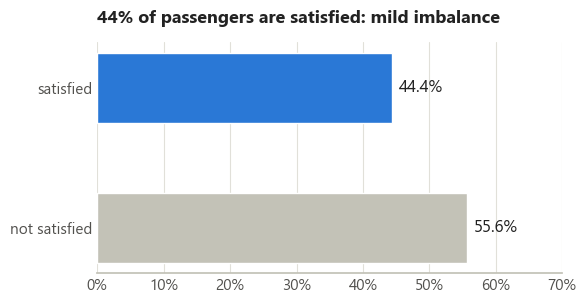

In [7]:
share = y.value_counts(normalize=True).rename({0: 'not satisfied', 1: 'satisfied'})
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(share.index, share.values, color=[GRAY, BLUE], height=0.5)
for i, v in enumerate(share.values):
    ax.text(v + 0.01, i, f'{v:.1%}', va='center', color=INK)
ax.xaxis.set_major_formatter(pct); ax.set_xlim(0, 0.7)
ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)
ax.set_title('44% of passengers are satisfied: mild imbalance')
plt.show()

**What we see:** 55.6% not satisfied, 44.4% satisfied.

**Decision:** no resampling and no class weights. ROC-AUC only looks at the *ranking* of predictions, so it is not affected by a mild imbalance. Cross-validation folds are **stratified** (every fold keeps the 44/56 split), so fold scores are comparable.

## 5. Distributions of the numeric columns

**Question:** what do age, flight distance and delays look like?

**Why it matters:** skewed columns, spikes and long tails decide which transformations a model may need (trees are indifferent to scale; neural networks are not).

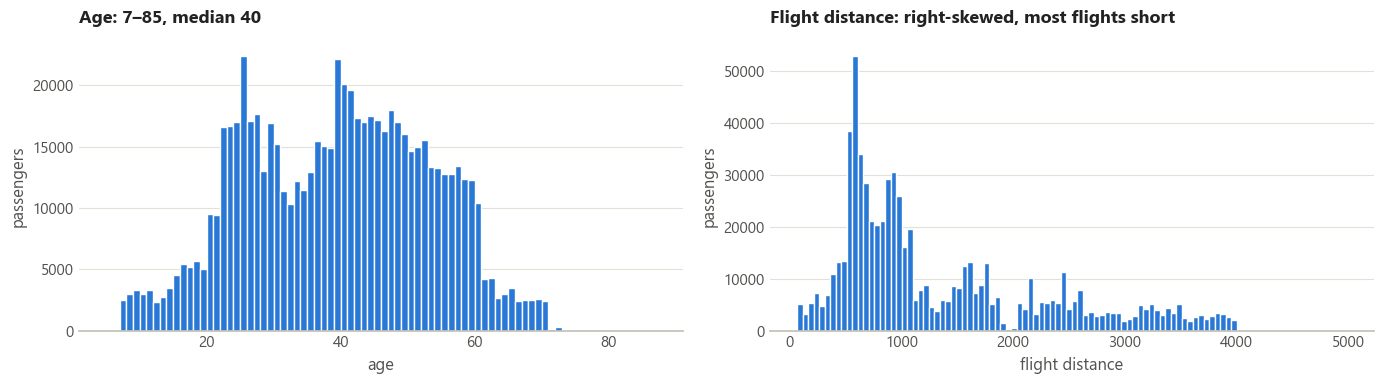

age range 7–85 | flight distance 67–4983, share under 1000: 53%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['age'], bins=np.arange(5, 88, 1), color=BLUE)
axes[0].set_xlabel('age'); axes[0].set_ylabel('passengers')
axes[0].set_title(f"Age: 7–85, median {train['age'].median():.0f}")

axes[1].hist(train['flight_distance'], bins=100, color=BLUE)
axes[1].set_xlabel('flight distance'); axes[1].set_ylabel('passengers')
axes[1].set_title('Flight distance: right-skewed, most flights short')
plt.tight_layout(); plt.show()

short = (train['flight_distance'] < 1000).mean()
print(f"age range {train['age'].min()}–{train['age'].max()} | flight distance {train['flight_distance'].min()}–"
      f"{train['flight_distance'].max()}, share under 1000: {short:.0%}")

departure delay = 0: 90.8% | arrival delay = 0: 91.5% | departure delay > 60 min: 353 rows | max 489 min


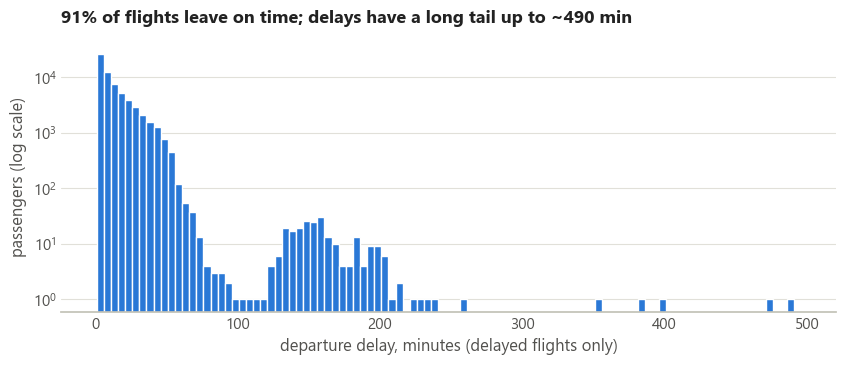

In [9]:
# Delays: most flights are on time, so we show the share of zeros and, separately, the delayed flights on a log scale.
dep = train['departure_delay_in_minutes']
print(f"departure delay = 0: {(dep == 0).mean():.1%} | arrival delay = 0: {(train['arrival_delay_in_minutes'] == 0).mean():.1%} | "
      f"departure delay > 60 min: {(dep > 60).sum()} rows | max {dep.max()} min")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(dep[dep > 0], bins=np.arange(1, 500, 5), color=BLUE)
ax.set_yscale('log')                                   # log scale: otherwise the long tail is invisible
ax.set_xlabel('departure delay, minutes (delayed flights only)'); ax.set_ylabel('passengers (log scale)')
ax.set_title('91% of flights leave on time; delays have a long tail up to ~490 min')
plt.show()

**What we see**
- **Age** 7–85, median 40, no impossible values.
- **Flight distance** 67–4,983, right-skewed: 53% of flights are under 1,000.
- **Delays:** 90.8% of departures and 91.5% of arrivals have zero delay; the delayed ones fall off quickly but reach ~490 minutes.

**Decision:** keep the raw values. Trees do not need transformations. For neural networks, scaling is done inside their own pipelines (`06`, `07`); a log-transform of the delays is not needed for trees.

## 6. Each feature against the target

**Question:** which features separate satisfied from unsatisfied passengers, and *in what shape* (straight line, threshold, U-shape)?

**Why it matters:** the shape of the relationship tells us whether a model will find the signal on its own (trees find thresholds easily) and which features deserve extra work.

The tool everywhere is the **satisfaction rate per value**: group passengers by the value of a feature and take the share of satisfied ones.

### 6.1 Categories

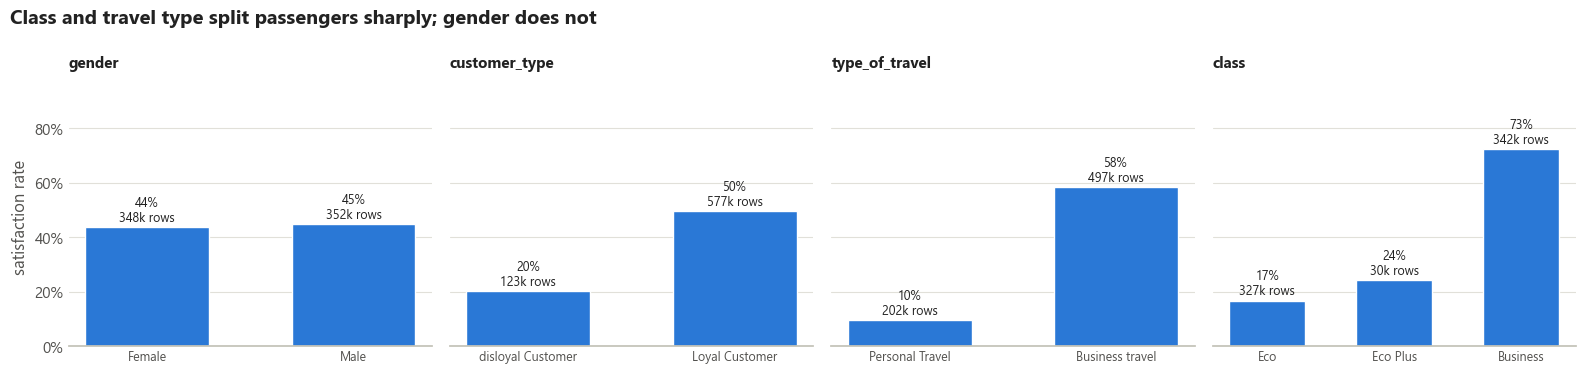

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, col in zip(axes, CAT_COLS):
    g = y.groupby(train[col]).agg(['mean', 'size']).sort_values('mean')
    ax.bar(g.index.astype(str), g['mean'], color=BLUE, width=0.6)
    for i, (rate, n) in enumerate(zip(g['mean'], g['size'])):
        ax.text(i, rate + 0.02, f'{rate:.0%}\n{n / 1e3:.0f}k rows', ha='center', color=INK, fontsize=9)
    ax.set_title(col, fontsize=11); ax.yaxis.set_major_formatter(pct); ax.set_ylim(0, 0.95)
    ax.tick_params(axis='x', labelsize=9)
axes[0].set_ylabel('satisfaction rate')
fig.suptitle('Class and travel type split passengers sharply; gender does not', x=0.01, ha='left', fontweight='bold')
plt.tight_layout(); plt.show()

**What we see**

| Column | Satisfaction rate | Reading |
|---|---|---|
| `type_of_travel` | business 58% vs personal **10%** | very strong |
| `class` | Business 73%, Eco Plus 24%, Eco **17%** | very strong; Eco Plus is between Business and Eco, closer to Eco |
| `customer_type` | loyal 50% vs disloyal 20% | strong |
| `gender` | 44% vs 45% | none |

**Decision:** pass the four columns to the model as categories (LightGBM, CatBoost and XGBoost use them natively). `gender` stays: removing it was tested in `02` (E6) and did not help.

### 6.2 Service ratings

13 small charts, one per rating. The grey bar is the value **0**, which is outside the 1–5 scale.

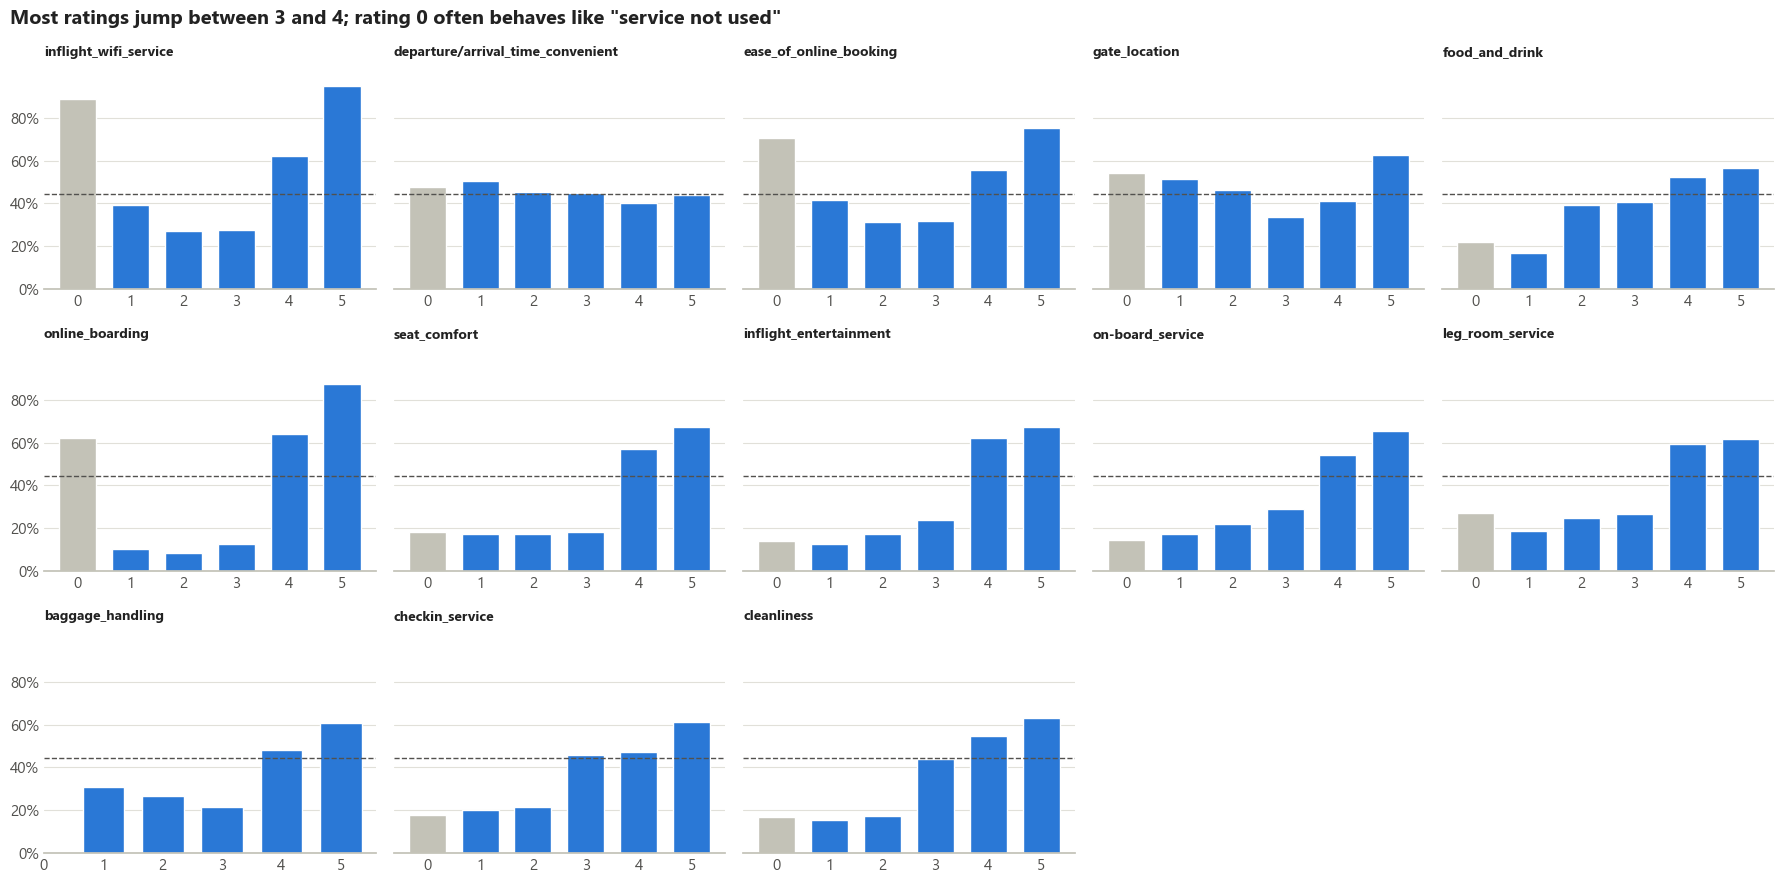

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(18, 9), sharey=True)
for ax, col in zip(axes.flat, RATING_COLS):
    rate = y.groupby(train[col]).mean()
    colors = [GRAY if v == 0 else BLUE for v in rate.index]   # 0 = special value
    ax.bar(rate.index, rate.values, color=colors, width=0.7)
    ax.axhline(y.mean(), color=MUTED, linewidth=1, linestyle='--')   # overall rate (44%) for reference
    ax.set_title(col, fontsize=10); ax.set_xticks(range(6)); ax.yaxis.set_major_formatter(pct)
for ax in axes.flat[len(RATING_COLS):]:
    ax.axis('off')
fig.suptitle('Most ratings jump between 3 and 4; rating 0 often behaves like "service not used"', x=0.01, ha='left', fontweight='bold')
plt.tight_layout(); plt.show()

In [12]:
# Share of zeros per rating and the satisfaction rate of those passengers
zeros = pd.DataFrame({
    'share of 0': (train[RATING_COLS] == 0).mean(),
    'rate at 0': [y[train[c] == 0].mean() if (train[c] == 0).any() else np.nan for c in RATING_COLS],
    'rate at 1-3': [y[train[c].between(1, 3)].mean() for c in RATING_COLS],
    'rate at 4-5': [y[train[c] >= 4].mean() for c in RATING_COLS],
}).sort_values('share of 0', ascending=False)
zeros

,share of 0,rate at 0,rate at 1-3,rate at 4-5
departure/arrival_time_convenient,0.037,0.478,0.467,0.418
ease_of_online_booking,0.023,0.708,0.341,0.638
inflight_wifi_service,0.019,0.887,0.300,0.748
online_boarding,0.013,0.620,0.109,0.740
leg_room_service,0.002,0.270,0.246,0.604
gate_location,0.002,0.543,0.418,0.486
inflight_entertainment,0.001,0.140,0.189,0.643
food_and_drink,0.001,0.219,0.357,0.545
cleanliness,0.001,0.168,0.300,0.584
checkin_service,0.001,0.179,0.356,0.528


**What we see**
- **The typical shape is a threshold, not a straight line:** the satisfaction rate stays low for ratings 1–3 and jumps at 4. Example: `online_boarding` 9–13% for 1–3, then 64% at 4 and 88% at 5.
- **Not every rating is monotonic.** `inflight_wifi_service` is U-shaped (rating 1: 39%, 2–3: 27–28%, 5: 95%). `departure/arrival_time_convenient` is almost flat (40–51%). `gate_location` moves up and down.
- **Rating 0 is not "the worst rating".** Passengers who gave 0 to wifi are 89% satisfied, to online boarding 62%, to online booking 71%. Zeros are concentrated in these digital services and in time convenience (1.3–3.7% of rows); elsewhere they are rare (≈ 0.1–0.2%), and `baggage_handling` has none. The most likely meaning: **"did not use the service"**.

**Decision:** keep ratings as numbers. Trees find the 3/4 threshold and can isolate 0 with one split. Two ideas from here were tested in `02`: ratings as categories (E7) and rating aggregates with 0 treated as missing (E1); neither helped.

### 6.3 Delays: is there a threshold?

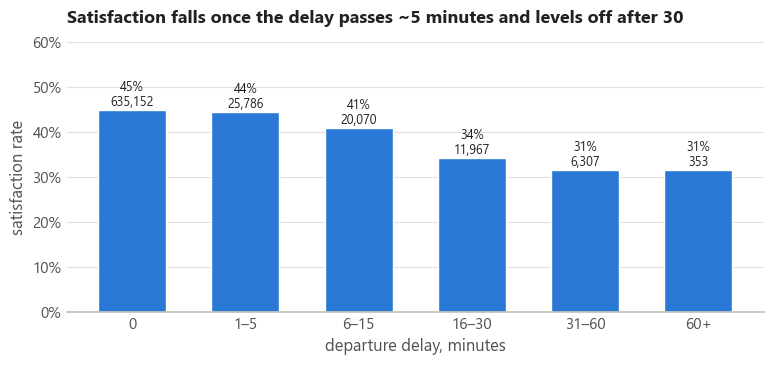

In [13]:
buckets = pd.cut(train['departure_delay_in_minutes'], bins=[-1, 0, 5, 15, 30, 60, 10_000],
                 labels=['0', '1–5', '6–15', '16–30', '31–60', '60+'])
bucket_stats = y.groupby(buckets, observed=True).agg(rate='mean', passengers='size')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(bucket_stats.index.astype(str), bucket_stats['rate'], color=BLUE, width=0.6)
for i, (r, n) in enumerate(zip(bucket_stats['rate'], bucket_stats['passengers'])):
    ax.text(i, r + 0.01, f'{r:.0%}\n{n:,}', ha='center', color=INK, fontsize=9)
ax.yaxis.set_major_formatter(pct); ax.set_ylim(0, 0.6)
ax.set_xlabel('departure delay, minutes'); ax.set_ylabel('satisfaction rate')
ax.set_title('Satisfaction falls once the delay passes ~5 minutes and levels off after 30')
plt.show()

**What we see:** 45% satisfied when on time, the same up to 5 minutes, then 41% (6–15 min), 34% (16–30 min) and 31% beyond 30 minutes. The effect is real but concerns only 9% of passengers, which is why delays have little weight overall (section 10).

**Decision:** no delay buckets as features. A tree finds these thresholds on the raw minutes by itself; `02` showed that hand-made bins of a numeric column do not help a tree (E10, E15).

### 6.4 Age and flight distance: smooth trend, or something else?

For age and distance we plot the satisfaction rate **per exact value**. If the column were an ordinary measurement, neighbouring values would have similar rates and the curve would be smooth up to sampling noise.

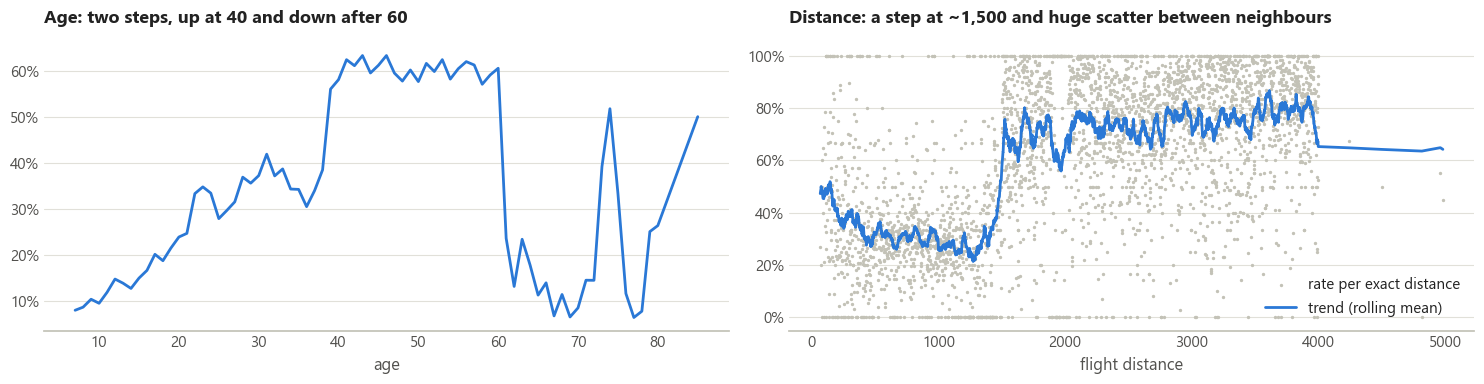

standardised scatter of per-distance rates: 5.1  (pure sampling noise would give 1.0) | 1040 distance values

satisfaction rate by age group:
age
(0, 15]     12%
(15, 25]    28%
(25, 35]    35%
(35, 45]    53%
(45, 60]    60%
(60, 70]    14%
(70, 90]    17%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

rate_age = y.groupby(train['age']).mean()
axes[0].plot(rate_age.index, rate_age.values, color=BLUE)
axes[0].yaxis.set_major_formatter(pct); axes[0].set_xlabel('age')
axes[0].set_title('Age: two steps, up at 40 and down after 60')

g = y.groupby(train['flight_distance']).agg(['mean', 'size'])
smooth = g['mean'].rolling(51, center=True, min_periods=10).mean()       # trend over ~50 neighbouring distances
axes[1].scatter(g.index, g['mean'], s=2, color=GRAY, label='rate per exact distance')
axes[1].plot(smooth.index, smooth.values, color=BLUE, label='trend (rolling mean)')
axes[1].yaxis.set_major_formatter(pct); axes[1].set_xlabel('flight distance'); axes[1].legend(loc='lower right')
axes[1].set_title('Distance: a step at ~1,500 and huge scatter between neighbours')
plt.tight_layout(); plt.show()

# Is the scatter around the trend larger than sampling noise? Standardise each deviation by its own noise level:
# z = (rate - trend) / sqrt(p(1-p)/n). If distance were an ordinary measurement, z would have a standard deviation of about 1.
p = y.mean()
z = (g['mean'] - smooth) / np.sqrt(p * (1 - p) / g['size'])
z = z[g['size'] >= 100].dropna()                                        # values with at least 100 passengers (88% of rows)
print(f'standardised scatter of per-distance rates: {z.std():.1f}  (pure sampling noise would give 1.0) | {len(z)} distance values')

print()
print('satisfaction rate by age group:')
print(y.groupby(pd.cut(train['age'], [0, 15, 25, 35, 45, 60, 70, 90]), observed=True).mean().map('{:.0%}'.format).to_string())

**What we see**
- **Age is not monotonic and has two steps.** The rate climbs slowly from ≈ 10% (children) to ≈ 35% at the end of the thirties, **jumps to ≈ 60% at 40**, stays flat until 60 and **collapses to ≈ 10–20% after 60**. Sharp steps like these are typical of synthetic data generated by rules. A straight-line view ("older = more satisfied") would be wrong; a tree captures each step with one split.
- **Flight distance has a step too:** below ≈ 1,500 the rate is 25–40%, above it 65–80% (long flights are more often Business class).
- **More important: the rates of neighbouring distances scatter about 5 times more than sampling noise allows** (standardised scatter ≈ 5 instead of 1). Two distances that differ by 1 km can have very different satisfaction rates. This is how an *identifier* behaves, not a measurement: each distance value is effectively a **route** with its own character.

**Decision:** this is the key lead for feature engineering. A tree can only split distance by thresholds, so it cannot memorise 3,474 individual routes. Features that describe **each value** are promising: how often the value occurs (frequency), the satisfaction rate of its passengers (target encoding, computed inside the CV folds), and a profile of the route. These ideas were tested in `02` (E8, E12) and became the biggest gains of the project.

## 7. Correlations between features

**Question:** which columns largely repeat each other?

**Why it matters:** two near-identical columns add little; a group of correlated ratings suggests the passenger answers a "general impression" question several times.

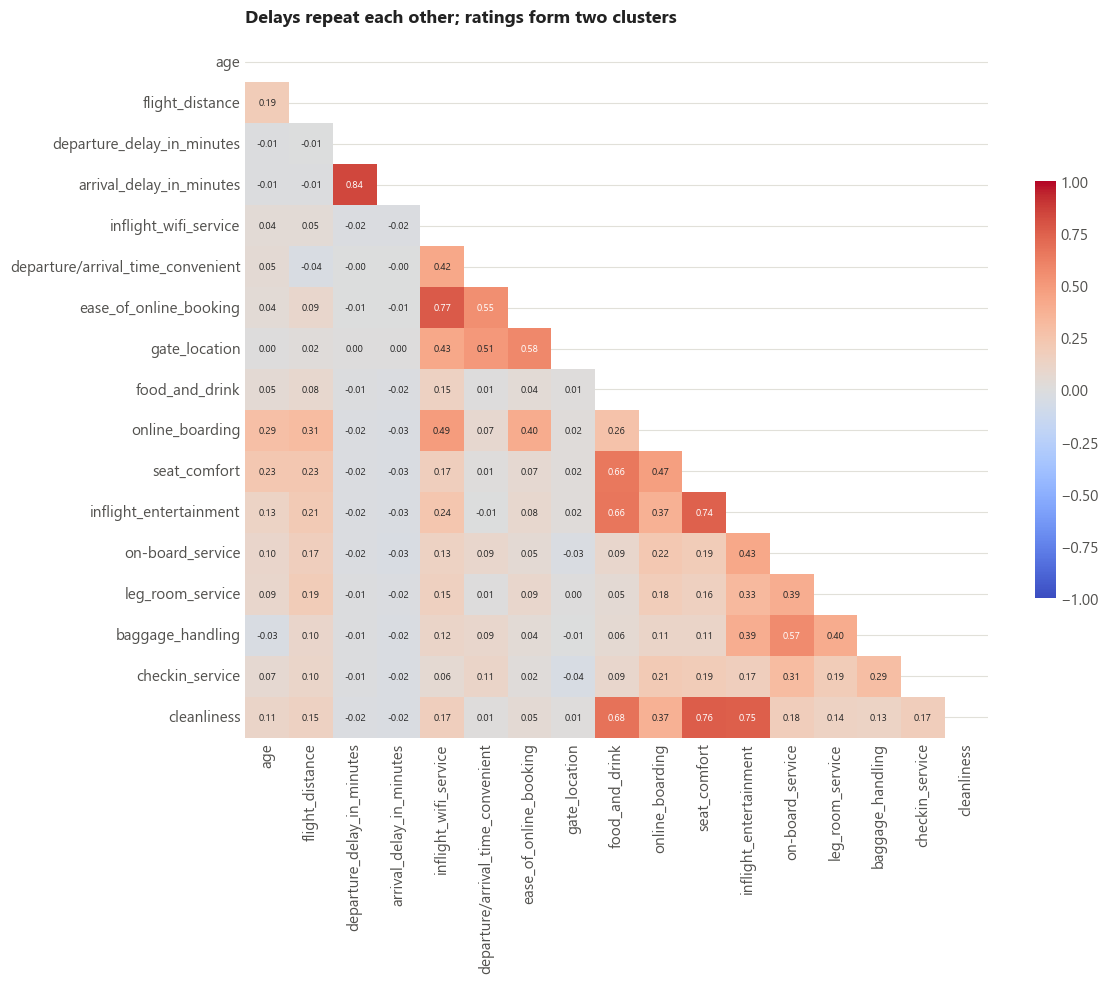

strongest pairs:
arrival_delay_in_minutes  departure_delay_in_minutes   0.840
ease_of_online_booking    inflight_wifi_service        0.770
cleanliness               seat_comfort                 0.760
                          inflight_entertainment       0.750
inflight_entertainment    seat_comfort                 0.740
cleanliness               food_and_drink               0.680
inflight_entertainment    food_and_drink               0.660
seat_comfort              food_and_drink               0.660


In [15]:
corr = train[NUM_COLS + RATING_COLS].corr()          # Pearson correlation between numeric columns
fig, ax = plt.subplots(figsize=(12, 10))
mask_upper = np.triu(np.ones_like(corr, dtype=bool))   # show each pair once
sns.heatmap(corr, mask=mask_upper, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.6}, ax=ax)
ax.set_title('Delays repeat each other; ratings form two clusters')
plt.tight_layout(); plt.show()

pairs = corr.where(~mask_upper).stack().sort_values(key=abs, ascending=False)
print('strongest pairs:'); print(pairs.head(8).round(2).to_string())

**What we see**
- **Departure and arrival delay: 0.84.** Strongly related, but not identical (a flight can make up or lose time in the air).
- **Two rating clusters:** *digital* (`inflight_wifi_service` – `ease_of_online_booking` 0.77) and *comfort* (`seat_comfort`, `cleanliness`, `inflight_entertainment`, `food_and_drink`: 0.68–0.76).
- Age and distance are almost unrelated to the other columns.

**Decision:** drop `arrival_delay_in_minutes` after using it to build the missing flag; the departure delay carries almost the same information. (The difference `arrival − departure` was tested in `02`, E2: no gain.) Keep all ratings: correlated is not identical, and trees are not harmed by correlated inputs.

## 8. Outliers

**Question:** are there impossible values (negative delays, ages over 100, distances of 0)?

**Why it matters:** data errors must be fixed or removed; real extreme values must be kept.

In [16]:
train[NUM_COLS].describe(percentiles=[0.01, 0.5, 0.99]).T

,count,mean,std,min,1%,50%,99%,max
age,699635.000,39.002,13.801,7.000,9.000,40.000,68.000,85.000
flight_distance,699635.000,1353.779,954.423,67.000,160.000,954.000,3873.000,4983.000
departure_delay_in_minutes,699635.000,1.176,5.982,0.000,0.000,0.000,30.000,489.000
arrival_delay_in_minutes,699343.000,1.134,5.749,0.000,0.000,0.000,28.000,491.000


**What we see:** all values are within plausible ranges: age 7–85, distance 67–4,983, delays 0 to ~490 minutes with no negative values. The 99th percentile of delays is far below the maximum: a long tail of real, rare extreme delays.

**Decision:** no rows are removed or clipped. Trees are insensitive to extreme values.

## 9. Train vs test: can we trust cross-validation?

**Question:** are train and test drawn from the same distribution, and does row order carry information?

**Why it matters:** cross-validation measures the score on train. It predicts the test score only if test looks like train. If row order in train were related to the target (e.g. rows sorted by date), shuffled folds would mislead.

We compare **every** column: the KS statistic for numeric columns and ratings, the largest difference in category shares for categorical columns.

In [17]:
rows = []
for col in NUM_COLS + RATING_COLS:
    ks = stats.ks_2samp(train[col].dropna(), test[col].dropna()).statistic
    rows.append({'column': col, 'measure': 'KS statistic', 'value': ks})
for col in CAT_COLS:
    diff = (train[col].value_counts(normalize=True) - test[col].value_counts(normalize=True)).abs().max()
    rows.append({'column': col, 'measure': 'max share difference', 'value': diff})
shift = pd.DataFrame(rows).sort_values('value', ascending=False)
print(f"largest train/test difference over all {len(shift)} columns: {shift['value'].max():.4f}")
shift.head(5)

largest train/test difference over all 21 columns: 0.0027


,column,measure,value
16,cleanliness,KS statistic,0.003
8,food_and_drink,KS statistic,0.002
12,on-board_service,KS statistic,0.002
13,leg_room_service,KS statistic,0.002
17,gender,max share difference,0.002


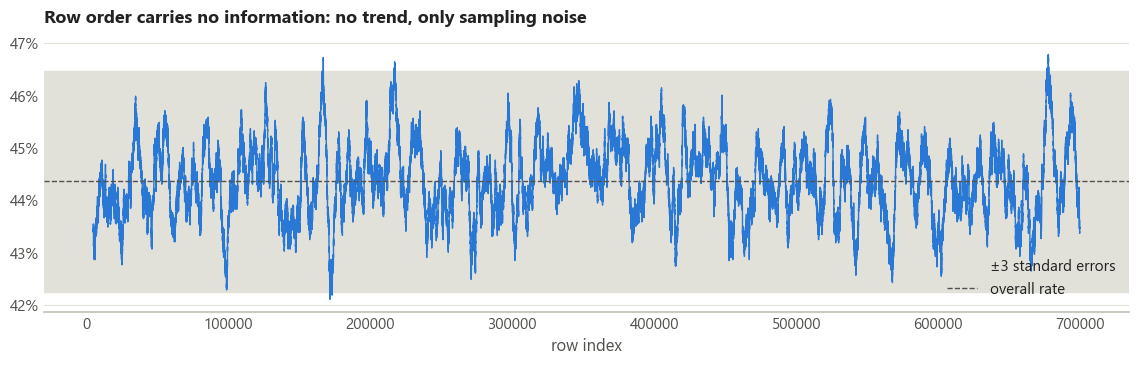

rolling rate: min 0.421, max 0.468 | noise band 0.422–0.465


In [18]:
# Row order: the satisfaction rate over a moving window of 5,000 rows should stay flat around the overall rate.
window = 5000
rolling = y.rolling(window).mean()
band = 3 * np.sqrt(y.mean() * (1 - y.mean()) / window)          # ±3 standard errors of a rate measured on 5,000 rows

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(rolling.values, color=BLUE, linewidth=1)
ax.axhspan(y.mean() - band, y.mean() + band, color=GRID, zorder=0, label='±3 standard errors')
ax.axhline(y.mean(), color=MUTED, linestyle='--', linewidth=1, label='overall rate')
ax.yaxis.set_major_formatter(pct); ax.set_xlabel('row index'); ax.legend(loc='lower right')
ax.set_title('Row order carries no information: no trend, only sampling noise')
plt.show()
print(f'rolling rate: min {rolling.min():.3f}, max {rolling.max():.3f} | noise band {y.mean() - band:.3f}–{y.mean() + band:.3f}')

**What we see**
- **No distribution shift:** the largest difference over all 21 columns is 0.003 (KS 0.0027 for `cleanliness`). For comparison, a KS statistic of 0.05 would already be a noticeable shift.
- **No row-order effect:** the rolling satisfaction rate shows no trend or step. Its extremes just touch the ±3 standard-error band, which is expected when ~140 independent windows are scanned.

**Decision:** ordinary `StratifiedKFold(5, shuffle=True, random_state=42)` is trustworthy, and the CV score should translate to the leaderboard. No adversarial validation is needed. The same folds are reused in every notebook so that model predictions can be compared and stacked.

## 10. Effect sizes: one number per feature

**Question:** which numeric features and ratings separate satisfied from unsatisfied passengers most strongly?

**Why it matters:** this gives a ranking of where the signal is. Section 6 showed the shapes; here we condense each feature to one comparable number.

**Method: Mann-Whitney U test.** It asks whether values in one group tend to be larger than in the other, without assuming a normal distribution.
- *H₀:* the feature is distributed the same way for satisfied and unsatisfied passengers.
- *H₁:* the distributions differ.

With 700,000 rows **every p-value is ≈ 0**, so the p-value tells us nothing useful. What matters is the **effect size**, the rank-biserial correlation `r = 1 − 2U / (n₁ · n₂)`, where `U` is computed for the *satisfied* group. **Negative r means satisfied passengers have larger values.** Rule of thumb: |r| < 0.1 weak, 0.1–0.3 medium, > 0.3 strong.

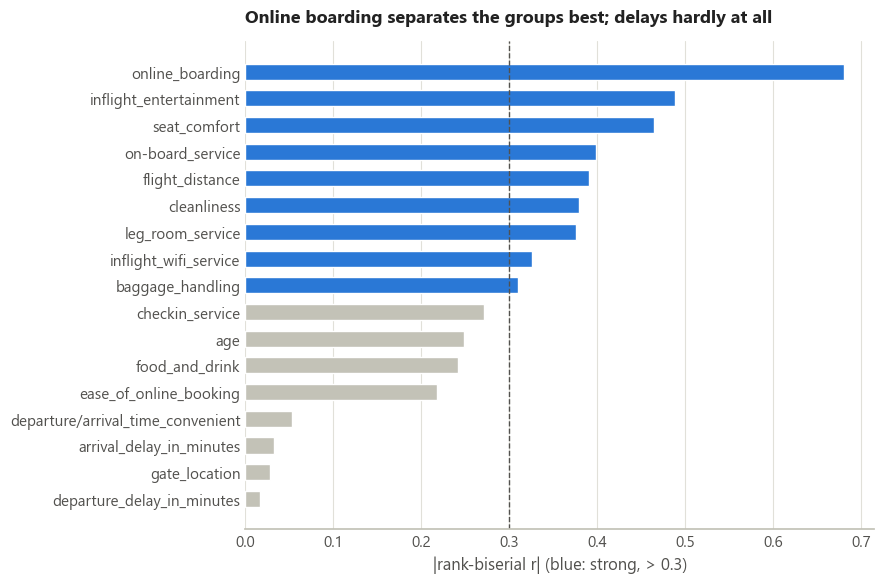

,r,|r|,strength,higher in
online_boarding,-0.681,0.681,strong,satisfied
inflight_entertainment,-0.489,0.489,strong,satisfied
seat_comfort,-0.464,0.464,strong,satisfied
on-board_service,-0.399,0.399,strong,satisfied
flight_distance,-0.391,0.391,strong,satisfied
cleanliness,-0.379,0.379,strong,satisfied
leg_room_service,-0.375,0.375,strong,satisfied
inflight_wifi_service,-0.325,0.325,strong,satisfied
baggage_handling,-0.310,0.310,strong,satisfied
checkin_service,-0.271,0.271,medium,satisfied


In [19]:
def rank_biserial(col):
    # Effect size of the Mann-Whitney test; U is computed for the satisfied group (passed first).
    values = train[col]
    sat, unsat = values[y == 1].dropna(), values[y == 0].dropna()
    u, _ = stats.mannwhitneyu(sat, unsat, alternative='two-sided')
    return 1 - 2 * u / (len(sat) * len(unsat))

effects = pd.DataFrame({'r': {col: rank_biserial(col) for col in NUM_COLS + RATING_COLS}})
effects['|r|'] = effects['r'].abs()
effects['strength'] = pd.cut(effects['|r|'], [0, 0.1, 0.3, 1], labels=['weak', 'medium', 'strong'])
effects['higher in'] = np.where(effects['r'] < 0, 'satisfied', 'not satisfied')
effects = effects.sort_values('|r|', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top = effects['|r|'][::-1]
ax.barh(top.index, top.values, color=[BLUE if v > 0.3 else GRAY for v in top.values], height=0.6)
ax.axvline(0.3, color=MUTED, linestyle='--', linewidth=1)
ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)
ax.set_xlabel('|rank-biserial r| (blue: strong, > 0.3)')
ax.set_title('Online boarding separates the groups best; delays hardly at all')
plt.tight_layout(); plt.show()
effects.round(3)

**What we see**
- **Strongest:** `online_boarding` (r = −0.68), then `inflight_entertainment`, `seat_comfort`, `on-board_service`, `flight_distance` (−0.39), `cleanliness`, `leg_room_service`, `inflight_wifi_service`, `baggage_handling`. For all of them satisfied passengers have higher values.
- **Medium:** `checkin_service`, `age` (−0.25), `food_and_drink`, `ease_of_online_booking`.
- **Weak:** delays (`departure_delay` r = +0.02; the effect exists, but only for the 9% delayed passengers, section 6.3), `departure/arrival_time_convenient`, `gate_location`.

**Two cautions: a single number hides the shape.**
- `age` gets a "medium" r of −0.25, which reads as "older passengers are more satisfied". Section 6.4 shows the real shape: a rise up to 60 and a collapse after it. A rank test cannot express that.
- `flight_distance` is treated as a smooth number and gets a strong effect. The test cannot see that *individual* distance values behave like routes (section 6.4). The largest gains of the project came from that per-value information, not from anything this ranking suggests.

## 11. Findings → decisions

| # | Finding | Decision | Where it is used / tested |
|---|---|---|---|
| 1 | No duplicates; `id` is a row number | drop `id` | `01`, `03` |
| 2 | 292 missing `arrival_delay` (0.04%), slightly less satisfied | fill with departure delay **and** add flag `arrival_delay_missing` | `01`, `03` |
| 3 | Mild imbalance (44% satisfied); metric is ROC-AUC | no resampling; stratified 5-fold CV | all notebooks |
| 4 | No train/test shift (max difference 0.003), no row-order effect | trust CV; the same folds everywhere | all notebooks |
| 5 | Departure and arrival delay correlate at 0.84 | keep departure delay only | `01`; `delay_diff` tested in `02` E2: no gain |
| 6 | Ratings act as thresholds (jump at 3 → 4); some are U-shaped or flat | keep as numbers; trees find thresholds | ratings as categories: `02` E7, no gain |
| 7 | Rating 0 ≈ "service not used" (wifi 0 → 89% satisfied) | keep 0 as a value | aggregates ignoring 0: `02` E1, no gain |
| 8 | Strong categories: travel type, class, loyalty; gender none | native categorical columns | `01` onwards |
| 9 | Delay hurts only above ~5 min and concerns 9% of passengers | raw minutes, no buckets | bins: `02` E10/E15, no gain |
| 10 | Age and distance have sharp steps (age 40 and 60, distance ≈ 1,500) | keep raw values; a tree captures a step with one split | `01` onwards |
| 11 | **`flight_distance` behaves like a route ID** (3,474 values, rates scatter ≈ 5× beyond noise) | describe each value: frequency, target encoding, route profile | `02` E8 (+0.00059), E12 (+0.00051); `03` route profile |
| 12 | Strongest single signal: `online_boarding`, then entertainment, seat comfort, service | nothing to engineer: models find them | `02` §10 confirms with model importance |

### Hypotheses for feature engineering and what happened to them

| Hypothesis from EDA | Tested in | Result |
|---|---|---|
| Row-wise rating aggregates (mean, min, count of low ratings) | `02` E1 | −0.00021, rejected |
| Delay difference arrival − departure | `02` E2 | −0.00001, rejected |
| Segments: Business × long flight, young × personal travel, loyal × delay | `02` E4 (class × travel × loyalty) | +0.00008, noise |
| Ratings as categories (0 is special) | `02` E7 | −0.00013, rejected |
| Delay buckets | `02` E10/E15 (bins) | no gain |
| Per-value information about `flight_distance` | `02` E8, E9, E12; `03` | **+0.0013 in total: the main gain of the project** |

**Lesson.** EDA showed clearly *where* the signal is (online boarding, class, travel type), but models find those signals on their own. The improvement came from the one finding that is invisible to a model reading a single row: that a distance value identifies a group of passengers. **When doing EDA for a model, look not only at "which feature is strong" but also at "what can a model *not* see from one row".**